# Parallel `decode_batch` Speedup Benchmark

Measures wall-clock speedup of `parallel=True` vs `parallel=False` for BP and MemBP decoders on the BB [[144, 12, 12]] code with circuit-level noise.

In [1]:
%reload_ext autoreload
%autoreload 2

import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from qecdec.experiments import StimFileExperiment
from qecdec.decoders import Decoder, BPDecoder, MemBPDecoder

## Setup: Load BB [[144, 12, 12]] experiment and sample syndromes

In [2]:
n, k, d = 144, 12, 12
rounds = d
code_name = f"BB_{n}_{k}_{d}"
noise_model = "CircuitLevel"
error_rate = 0.003
basis = "Z"

circuit_file = Path(
    f"../../../circuits/{code_name}_{noise_model}/d={d}_rounds={rounds}_basis={basis}/error_rate={error_rate}.stim"
).resolve()

expmt = StimFileExperiment.load_from_file(circuit_file, basis)
pcm, prior = expmt.chkmat, expmt.prior
print(f"PCM shape: (num_chks={pcm.shape[0]}, num_vars={pcm.shape[1]})")

PCM shape: (num_chks=936, num_vars=8784)


In [3]:
# Sample syndromes for benchmarking
max_batch_size = 10_000
sampler = expmt.dem.compile_sampler()
syndromes_all, _, _ = sampler.sample(max_batch_size)
syndromes_all = syndromes_all.astype(np.uint8)
print(
    f"Sampled {syndromes_all.shape[0]} syndrome vectors, each of length {syndromes_all.shape[1]}"
)

Sampled 10000 syndrome vectors, each of length 936


## Benchmark helper

In [4]:
def benchmark_decode_batch(
    decoder: Decoder,
    syndromes: np.ndarray,
    *,
    parallel: bool,
    warmup: int = 1,
    repeats: int = 5,
):
    """Time decode_batch and return median wall-clock time in seconds."""
    # Warmup runs (not timed)
    for _ in range(warmup):
        decoder.decode_batch(syndromes, parallel=parallel)

    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        decoder.decode_batch(syndromes, parallel=parallel)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return np.median(times)

## Speedup vs batch size

Sweep batch sizes from 100 to 10000 and measure sequential vs parallel wall-clock time for both BP and MemBP.

In [5]:
print(f"Number of logical CPUs: {os.cpu_count()}")

Number of logical CPUs: 32


In [6]:
max_iter = 50

bp = BPDecoder(pcm, prior, max_iter=max_iter)
membp = MemBPDecoder(pcm, prior, gamma=0.2, max_iter=max_iter)

batch_sizes = [100, 200, 500, 1000, 2000, 5000, 10000]

results = {}  # decoder_name -> {batch_size -> {seq_time, par_time, speedup}}

for name, decoder in [("BP", bp), ("MemBP", membp)]:
    results[name] = {}
    for bs in batch_sizes:
        syndromes = syndromes_all[:bs]
        t_seq = benchmark_decode_batch(decoder, syndromes, parallel=False)
        t_par = benchmark_decode_batch(decoder, syndromes, parallel=True)
        speedup = t_seq / t_par
        results[name][bs] = {"seq": t_seq, "par": t_par, "speedup": speedup}
        print(
            f"{name}  batch_size={bs:>5d}  seq={t_seq:.4f}s  par={t_par:.4f}s  speedup={speedup:.2f}x"
        )

BP  batch_size=  100  seq=0.5208s  par=0.0607s  speedup=8.58x
BP  batch_size=  200  seq=0.9615s  par=0.1086s  speedup=8.85x
BP  batch_size=  500  seq=2.3799s  par=0.1860s  speedup=12.80x
BP  batch_size= 1000  seq=4.7286s  par=0.3651s  speedup=12.95x
BP  batch_size= 2000  seq=9.4717s  par=0.7345s  speedup=12.90x
BP  batch_size= 5000  seq=23.6335s  par=1.7944s  speedup=13.17x
BP  batch_size=10000  seq=46.8985s  par=3.5796s  speedup=13.10x
MemBP  batch_size=  100  seq=0.2882s  par=0.0278s  speedup=10.37x
MemBP  batch_size=  200  seq=0.5513s  par=0.0515s  speedup=10.70x
MemBP  batch_size=  500  seq=1.3813s  par=0.1122s  speedup=12.32x
MemBP  batch_size= 1000  seq=2.7017s  par=0.2136s  speedup=12.65x
MemBP  batch_size= 2000  seq=5.1766s  par=0.4191s  speedup=12.35x
MemBP  batch_size= 5000  seq=12.9427s  par=1.0427s  speedup=12.41x
MemBP  batch_size=10000  seq=25.8055s  par=2.0733s  speedup=12.45x


## Plot results

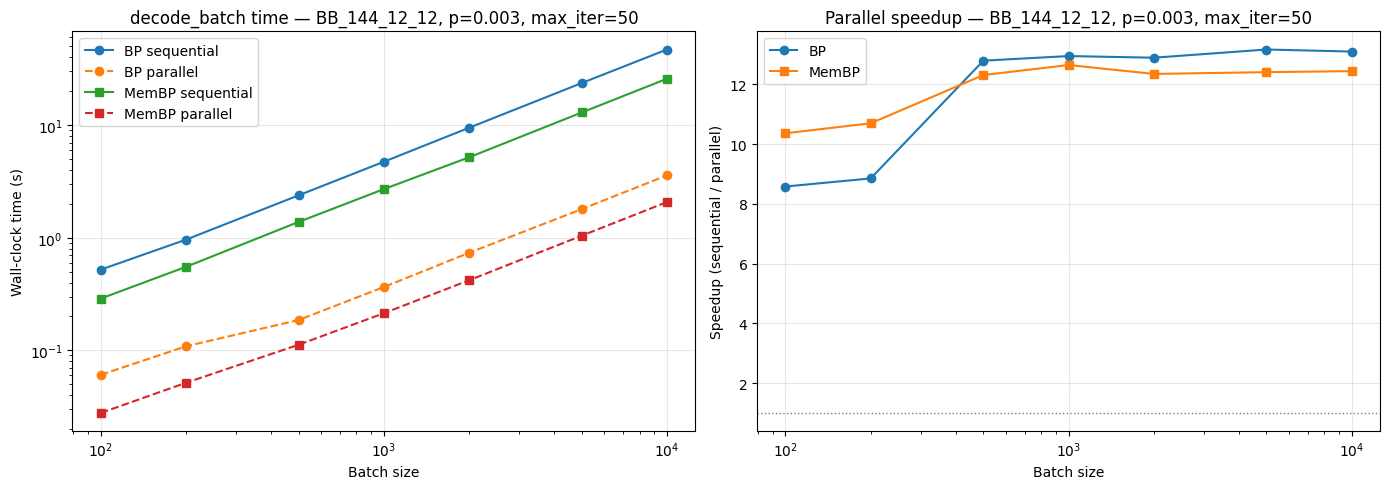

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: wall-clock time ---
ax = axes[0]
for name, marker in [("BP", "o"), ("MemBP", "s")]:
    bs_list = sorted(results[name].keys())
    seq_times = [results[name][bs]["seq"] for bs in bs_list]
    par_times = [results[name][bs]["par"] for bs in bs_list]
    ax.plot(bs_list, seq_times, f"-{marker}", label=f"{name} sequential")
    ax.plot(bs_list, par_times, f"--{marker}", label=f"{name} parallel")

ax.set_xlabel("Batch size")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title(f"decode_batch time — {code_name}, p={error_rate}, max_iter={max_iter}")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale("log")
ax.set_yscale("log")

# --- Right panel: speedup ---
ax = axes[1]
for name, marker in [("BP", "o"), ("MemBP", "s")]:
    bs_list = sorted(results[name].keys())
    speedups = [results[name][bs]["speedup"] for bs in bs_list]
    ax.plot(bs_list, speedups, f"-{marker}", label=name)

ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Batch size")
ax.set_ylabel("Speedup (sequential / parallel)")
ax.set_title(f"Parallel speedup — {code_name}, p={error_rate}, max_iter={max_iter}")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale("log")

fig.tight_layout()
plt.show()
